In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [111]:
df = pd.read_csv("dataset.csv")

In [112]:
df.head(5)

,age,experience_years,experience_proxy,monthly_ad_spend,website_visits,team_size,customer_rating,region,business_type,subscription_plan,noise_feature_1,noise_feature_2,annual_revenue
0,23,0,-1.28,120217.22,394762,8,4.01,Alexandria,Ecommerce,Standard,-294.95,-18.61,240086.12
1,51,29,28.75,54622.52,183214,56,2.89,Cairo,Services,Basic,-461.02,44.49,274237.97
2,46,20,23.79,41675.76,113096,141,2.89,Upper_Egypt,Manufacturing,Basic,-2156.89,-15.63,294387.86
3,37,13,15.73,13457.42,41326,91,4.64,Cairo,Services,Standard,682.77,21.51,247522.89
4,37,14,13.88,9281.03,11671,93,3.28,Cairo,Services,Standard,-1233.05,38.27,226068.17


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1200 non-null   int64  
 1   experience_years   1200 non-null   int64  
 2   experience_proxy   1200 non-null   float64
 3   monthly_ad_spend   1200 non-null   float64
 4   website_visits     1200 non-null   int64  
 5   team_size          1200 non-null   int64  
 6   customer_rating    1200 non-null   float64
 7   region             1200 non-null   object 
 8   business_type      1200 non-null   object 
 9   subscription_plan  1200 non-null   object 
 10  noise_feature_1    1200 non-null   float64
 11  noise_feature_2    1200 non-null   float64
 12  annual_revenue     1200 non-null   float64
dtypes: float64(6), int64(4), object(3)
memory usage: 122.0+ KB


In [114]:
df.describe()

,age,experience_years,experience_proxy,monthly_ad_spend,website_visits,team_size,customer_rating,noise_feature_1,noise_feature_2,annual_revenue
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,40.162500,18.307500,18.779933,24208.585867,65729.14000,74.217500,3.755708,-49.640983,-1.071300,233149.783258
std,11.797333,11.743986,12.174497,20618.049145,57825.13094,42.933724,0.714649,974.443011,28.532477,49740.754481
min,20.000000,0.000000,-2.940000,2104.830000,1000.00000,2.000000,2.500000,-2974.400000,-49.980000,102938.820000
25%,30.000000,7.750000,7.937500,10991.792500,29632.25000,38.000000,3.160000,-708.180000,-25.800000,198259.660000
50%,40.000000,19.000000,19.095000,18147.650000,49457.50000,72.000000,3.780000,-38.625000,-1.710000,232717.490000
75%,51.000000,28.000000,28.915000,31169.412500,83946.75000,111.000000,4.350000,564.887500,23.482500,266027.432500
max,60.000000,38.000000,42.130000,180000.000000,544599.00000,150.000000,5.000000,4151.240000,49.970000,415128.670000


In [115]:
df = df.drop(columns=['region', 'business_type', 'subscription_plan'])

<Axes: >

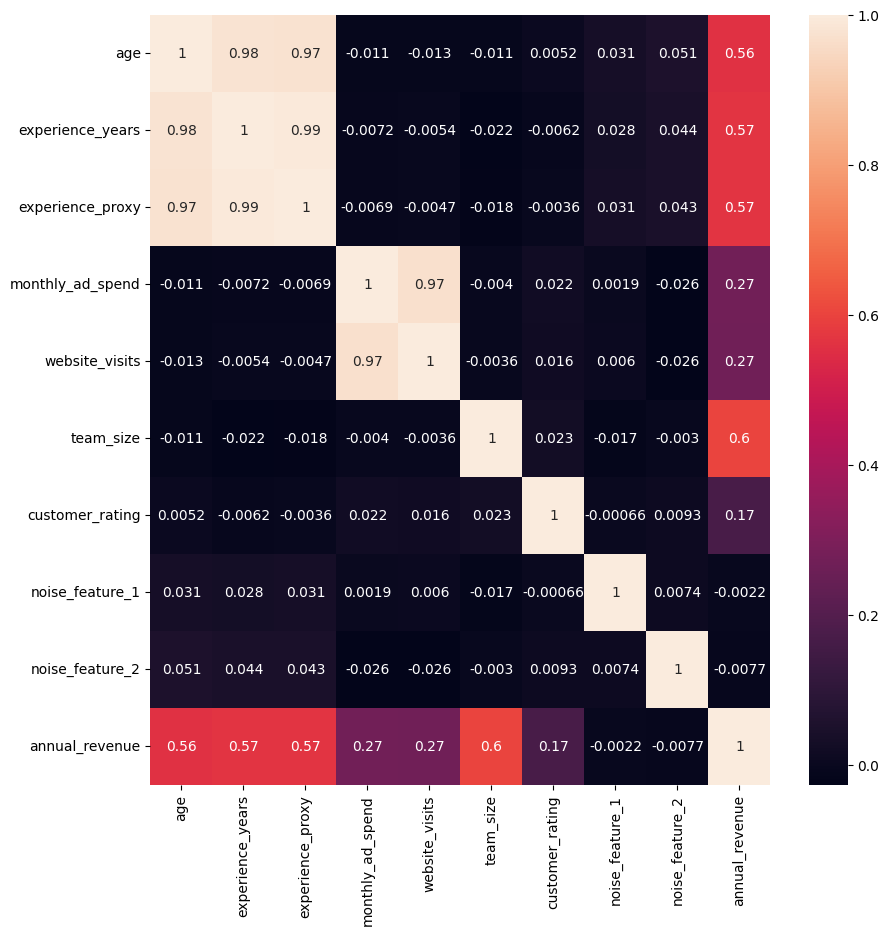

In [116]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True,)

In [117]:
X = df.drop('annual_revenue',axis=1)
y = df['annual_revenue']

In [118]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [119]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [120]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [121]:
print("Coefficient : ", lr.coef_)
print("Intercept : ", lr.intercept_)

Coefficient :  [-1452.55448667 25272.86966236  4715.9090756   9887.95299007
  3652.33402862 30462.81972288  7033.25327257  -372.82262073
 -1058.95659252]
Intercept :  233034.6249375


In [122]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [123]:
y_pred_test=lr.predict(X_test)

In [124]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred_test)
print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)
print("r2score : ", score)


mse :  457063210.96316606
mae :  16958.06649490268
rmse :  21379.03671738196
r2score :  0.8156839036930641


In [125]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8084715347071405

In [126]:
error_percentage = (16958 / y_test.mean()) * 100
print(f"Average Error Rate: %{error_percentage:.2f}")

Average Error Rate: %7.26


In [127]:
import pandas as pd

errors = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test,
    'Difference': abs(y_test - y_pred_test)
}).sort_values(by='Difference', ascending=False)

print(errors.head())

        Actual      Predicted    Difference
442  121320.30  180573.090592  59252.790592
893  335015.25  281548.520879  53466.729121
668  326940.80  275208.580674  51732.219326
579  188949.76  137333.290920  51616.469080
126  133445.47  184390.460269  50944.990269


In [128]:
df= pd.read_csv("dataset.csv")

In [129]:
df.head(5)

,age,experience_years,experience_proxy,monthly_ad_spend,website_visits,team_size,customer_rating,region,business_type,subscription_plan,noise_feature_1,noise_feature_2,annual_revenue
0,23,0,-1.28,120217.22,394762,8,4.01,Alexandria,Ecommerce,Standard,-294.95,-18.61,240086.12
1,51,29,28.75,54622.52,183214,56,2.89,Cairo,Services,Basic,-461.02,44.49,274237.97
2,46,20,23.79,41675.76,113096,141,2.89,Upper_Egypt,Manufacturing,Basic,-2156.89,-15.63,294387.86
3,37,13,15.73,13457.42,41326,91,4.64,Cairo,Services,Standard,682.77,21.51,247522.89
4,37,14,13.88,9281.03,11671,93,3.28,Cairo,Services,Standard,-1233.05,38.27,226068.17


In [130]:
X = df.drop(columns=['annual_revenue'])
y = df['annual_revenue']

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [132]:
categorical_cols = ['region', 'business_type', 'subscription_plan']

In [133]:
from sklearn.preprocessing import OneHotEncoder

In [134]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [135]:
train_encoded = ohe.fit_transform(X_train[categorical_cols])
test_encoded = ohe.transform(X_test[categorical_cols])

In [136]:
encoded_cols = ohe.get_feature_names_out(categorical_cols)

In [137]:
df_train_encoded = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train.index)
df_test_encoded = pd.DataFrame(test_encoded, columns=encoded_cols, index=X_test.index)

In [138]:
X_train_final = pd.concat([X_train.drop(columns=categorical_cols), df_train_encoded], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), df_test_encoded], axis=1)

In [139]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_final)
X_test_scaled = sc.transform(X_test_final)

In [140]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [141]:
y_pred = lr.predict(X_test_scaled)

In [142]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)
print("r2score : ", score)

mse :  369469747.1552924
mae :  15700.84061293207
rmse :  19221.595853500105
r2score :  0.8527275933223244


In [143]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8449422678591874

In [144]:
error_percentage = (16958 / y_test.mean()) * 100
print(f"Average Error Rate: %{error_percentage:.2f}")

Average Error Rate: %7.33


In [145]:
import pandas as pd

errors = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test,
    'Difference': abs(y_test - y_pred_test)
}).sort_values(by='Difference', ascending=False)

print(errors.head())

         Actual      Predicted     Difference
321   136087.25  336132.786849  200045.536849
724   359998.14  190913.863342  169084.276658
1116  330151.16  170270.523969  159880.636031
461   148145.66  304749.830629  156604.170629
893   335015.25  185147.514260  149867.735740


In [146]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)
adscore = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)
print("r2score : ", score)
print("adjusted r2score : ", adscore)

mse :  369457218.2830756
mae :  15701.074571466053
rmse :  19221.2699445972
r2score :  0.8527325873906575
adjusted r2score :  0.8449475259311328


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.028e+10, tolerance: 2.363e+08
  model = cd_fast.enet_coordinate_descent(


In [147]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)
adscore = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)
print("r2score : ", score)
print("adjusted r2score : ", adscore)

mse :  369030126.85943526
mae :  15700.163653681937
rmse :  19210.15686712202
r2score :  0.8529028280729196
adjusted r2score :  0.8451267661208273


In [148]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
score = r2_score(y_test, y_pred)
adscore = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)
print("r2score : ", score)
print("adjusted r2score : ", adscore)

mse :  549302019.5006566
mae :  18690.836799561777
rmse :  23437.193080671084
r2score :  0.7810455902610959
adjusted r2score :  0.7694709078079379
